# Weed Simulation Baseline Experiment

This notebook checks the high-level experiment runner defined in
`scripts/weed_experiment.py`.

The notebook performs two checks:

1. Run one baseline simulation with a single parameter configuration.
2. Change one parameter, `pressure_coef`, and compare the results.

At this stage, no weed-removal policy is applied. Each simulation runs only
weed growth and neighbour-driven diffusion.

In [2]:
from pathlib import Path
import os

repo_root = Path.cwd().parents[0]
os.chdir(repo_root)

print(Path.cwd())

c:\Users\kazut\Documents\ChatGPT\cits4403_computational_model


## Load the input data

The simulator requires a GeoDataFrame containing:

- polygon geometries;
- postcode information;
- population density in people per square kilometre.

For the initial experiment, postcodes from 6000 to 6199 are used as the
Perth metropolitan study area.

In [3]:
from scripts.data_loader import load_locality_data


# Load locality polygons and population-density data.
localities = load_locality_data()

# Select postcodes used as the Perth metropolitan study area.
metro = localities[
    localities["postcode"]
    .astype(int)
    .between(6000, 6199)
].copy()

print(f"Number of polygons: {len(metro)}")
print(f"CRS: {metro.crs}")

metro[
    [
        "name",
        "postcode",
        "population_density_km2",
    ]
].head()

Number of polygons: 375
CRS: EPSG:7844


c:\Users\kazut\Documents\ChatGPT\cits4403_computational_model\scripts\data_loader.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  census["postcode"] = (


,name,postcode,population_density_km2
9,PALMYRA,6157,2345.786980
14,EAST FREMANTLE,6158,2106.591326
15,BICTON,6157,2345.786980
28,SUBIACO,6008,2255.266273
33,NORTHBRIDGE,6003,4293.051718


## Import the experiment runner

`ExperimentConfig` stores the parameters used by one simulation.

`run_experiment` creates a new `WeedCA` instance, runs the simulation and
returns the grid history together with summary metrics.

In [4]:
import importlib
import scripts.weed_experiment

importlib.reload(scripts.weed_experiment)

from scripts.weed_experiment import (
    ExperimentConfig,
    run_experiment,
)

## Check 1: Run one baseline configuration

The first check runs one simulation with the baseline parameters.

No removal policy is passed to `run_experiment`, so the active simulation
modes are:

- growth;
- diffusion.

The simulation runs for 100 abstract update steps.

In [5]:
# Define one baseline parameter configuration.
baseline_config = ExperimentConfig(
    pressure_coef=0.000783,
    cell_size=1000.0,
    w_min=0.05,
    w_max=1.0,
    growth_rate=0.02,
    diffusion_rate=0.01,
    carrying_capacity=1.0,
    steps=100,
    high_density_threshold=0.7,
    crs="EPSG:7850",
)

baseline_config

ExperimentConfig(pressure_coef=0.000783, cell_size=1000.0, w_min=0.05, w_max=1.0, growth_rate=0.02, diffusion_rate=0.01, carrying_capacity=1.0, steps=100, high_density_threshold=0.7, crs='EPSG:7850')

In [6]:
# Run the baseline simulation without a removal policy.
baseline_result = run_experiment(
    name="baseline",
    gdf=metro,
    config=baseline_config,
)

baseline_result.summary()

{'name': 'baseline',
 'steps': 100,
 'grid_height': 203,
 'grid_width': 124,
 'valid_cells': 6933,
 'initial_mean_weed': 0.8605745434761047,
 'final_mean_weed': 0.9814243912696838,
 'relative_change': 0.14042926171791265,
 'final_high_density_cells': 6933,
 'final_cost': 0.0}

In [7]:
print(f"Simulation modes: {baseline_result.modes}")
print(f"History shape: {baseline_result.history.shape}")
print(f"Cost history shape: {baseline_result.cost_history.shape}")
print(f"Mean-weed history shape: {baseline_result.mean_weed.shape}")

print(f"Initial mean weed index: {baseline_result.initial_mean:.4f}")
print(f"Final mean weed index: {baseline_result.final_mean:.4f}")
print(f"Relative change: {baseline_result.relative_change:.2%}")
print(f"Final cost: {baseline_result.final_cost:.2f}")

Simulation modes: ('growth', 'diffusion')
History shape: (101, 203, 124)
Cost history shape: (101,)
Mean-weed history shape: (101,)
Initial mean weed index: 0.8606
Final mean weed index: 0.9814
Relative change: 14.04%
Final cost: 0.00


## Plot the baseline history

The mean weed index is calculated over all valid simulation cells at each
step.

The high-density-cell count shows how many cells have a weed index greater
than or equal to the configured threshold of 0.7.

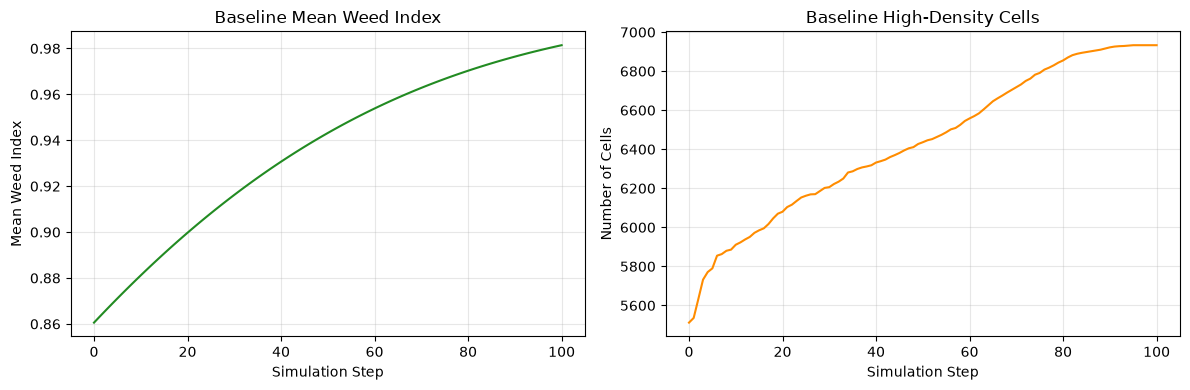

In [8]:
import matplotlib.pyplot as plt
import numpy as np


# Step zero represents the initial grid.
simulation_steps = np.arange(
    len(baseline_result.mean_weed)
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 4),
)

# Plot the mean weed index.
axes[0].plot(
    simulation_steps,
    baseline_result.mean_weed,
    color="forestgreen",
)

axes[0].set_title("Baseline Mean Weed Index")
axes[0].set_xlabel("Simulation Step")
axes[0].set_ylabel("Mean Weed Index")
axes[0].grid(alpha=0.3)

# Plot the number of high-density cells.
axes[1].plot(
    simulation_steps,
    baseline_result.high_density_cells,
    color="darkorange",
)

axes[1].set_title("Baseline High-Density Cells")
axes[1].set_xlabel("Simulation Step")
axes[1].set_ylabel("Number of Cells")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Check 2: Compare multiple pressure coefficients

This check changes only `pressure_coef`.

The initial weed index is calculated as:

$$
W = W_{\min} + (W_{\max} - W_{\min}) e^{-kD}
$$

where:

- $W$ is the initial weed index;
- $D$ is population density in people per square kilometre;
- $k$ is `pressure_coef`;
- $W_{\min}$ is the minimum initial weed index;
- $W_{\max}$ is the maximum initial weed index.

A larger `pressure_coef` makes the initial weed index decrease more rapidly
as population density increases.

All other simulation parameters remain unchanged, allowing the effect of
`pressure_coef` to be compared independently.

In [9]:
# Values of pressure_coef to compare.
pressure_coefficients = [
    0.0005,
    0.000783,
    0.001,
]

# Store each result using its coefficient as the dictionary key.
pressure_results = {}

for pressure_coef in pressure_coefficients:
    # Create a new configuration while changing only pressure_coef.
    config = ExperimentConfig(
        pressure_coef=pressure_coef,
        cell_size=1000.0,
        w_min=0.05,
        w_max=1.0,
        growth_rate=0.02,
        diffusion_rate=0.01,
        carrying_capacity=1.0,
        steps=100,
        high_density_threshold=0.7,
        crs="EPSG:7850",
    )

    # Give each experiment a unique and readable name.
    experiment_name = (
        f"baseline_pressure_{pressure_coef}"
    )

    # Run a completely new simulation for this configuration.
    result = run_experiment(
        name=experiment_name,
        gdf=metro,
        config=config,
    )

    pressure_results[pressure_coef] = result

print(
    f"Completed {len(pressure_results)} experiments."
)

Completed 3 experiments.


## Compare the experiment summaries

The table below compares:

- the initial mean weed index;
- the final mean weed index;
- the relative change over 100 steps;
- the final number of high-density cells;
- the final cumulative cost.

Because these are baseline runs without removal, the final cost should be
zero for every configuration.

In [10]:
import pandas as pd


# Convert each result summary into one table row.
summary_rows = [
    {
        "pressure_coef": pressure_coef,
        **result.summary(),
    }
    for pressure_coef, result
    in pressure_results.items()
]

pressure_summary = pd.DataFrame(
    summary_rows
)

# Select the most useful columns for this comparison.
pressure_summary = pressure_summary[
    [
        "pressure_coef",
        "initial_mean_weed",
        "final_mean_weed",
        "relative_change",
        "final_high_density_cells",
        "final_cost",
    ]
]

pressure_summary

,pressure_coef,initial_mean_weed,final_mean_weed,relative_change,final_high_density_cells,final_cost
0,0.000500,0.896954,0.988681,0.102265,6933,0.0
1,0.000783,0.860575,0.981424,0.140429,6933,0.0
2,0.001000,0.838777,0.975725,0.163271,6902,0.0


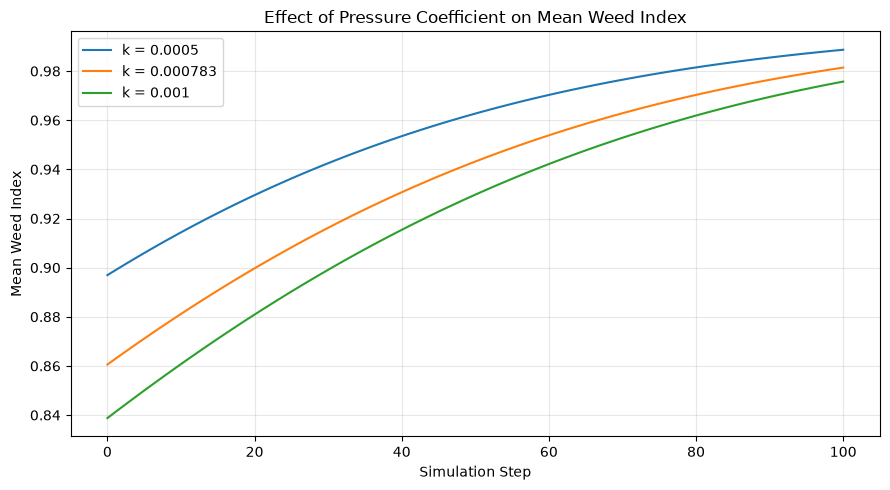

In [11]:
fig, ax = plt.subplots(
    figsize=(9, 5),
)

for pressure_coef, result in pressure_results.items():
    simulation_steps = np.arange(
        len(result.mean_weed)
    )

    ax.plot(
        simulation_steps,
        result.mean_weed,
        label=f"k = {pressure_coef}",
    )

ax.set_title(
    "Effect of Pressure Coefficient "
    "on Mean Weed Index"
)

ax.set_xlabel("Simulation Step")
ax.set_ylabel("Mean Weed Index")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

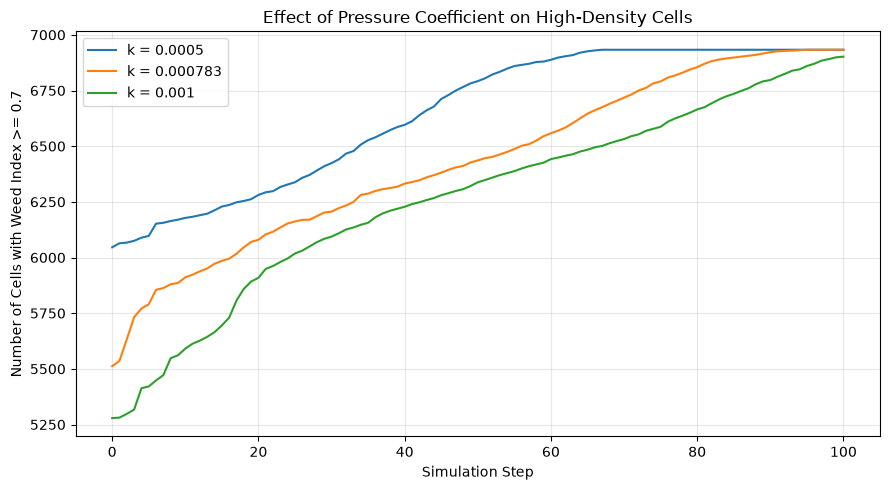

In [12]:
fig, ax = plt.subplots(
    figsize=(9, 5),
)

for pressure_coef, result in pressure_results.items():
    simulation_steps = np.arange(
        len(result.high_density_cells)
    )

    ax.plot(
        simulation_steps,
        result.high_density_cells,
        label=f"k = {pressure_coef}",
    )

ax.set_title(
    "Effect of Pressure Coefficient "
    "on High-Density Cells"
)

ax.set_xlabel("Simulation Step")
ax.set_ylabel(
    "Number of Cells with Weed Index >= 0.7"
)

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()